# Benchmark v5 — GPU — BACE — scaffold split, seed 1

**Task:** Binary — binds BACE-1 (1) or not (0)
**Size:** ~1,513 molecules
**Metric:** ROC-AUC ↑

**Scaffold split**, seed **1** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_1/scaffold/`.


In [2]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [3]:
DATASET_SLUG = "bace"
TASK_TYPE = "classification"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 100
LSTM_EPOCHS = 100
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 20
print(f"GPU HPO tier: standard — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 1

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: standard — 20 trials, 80 epochs/trial, batch=32
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold
Resuming 2 saved model(s): GIN (2D), D-MPNN (2D)
SPLIT_SEED=1  mode=scaffold


### Load data


In [4]:
import numpy as np
import pandas as pd

df = load_dataset("bace", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "bace")
print(f"Molecules : {len(smiles)}")
print(f"Class balance: {np.bincount(y.astype(int))}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'bace' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/bace.csv
INFO | [bace] 1513 / 1513 valid molecules


Molecules : 1513
Class balance: [822 691]
After bond filter: 1513 molecules


### Representations & scaffold split


In [5]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 1513 / 1513 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/bace_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/splits/bace_scaffold_splits.pkl


3D graphs loaded: 1513 / 1513 (valid_idx mapping)
{'n_total': 1513, 'n_train': 1210, 'n_val': 151, 'n_test': 152, 'n_scaffolds_total': 671, 'n_scaffolds_train': 368, 'n_scaffolds_val': 151, 'n_scaffolds_test': 152}


### GIN (2D)


In [6]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


Skipping GIN (2D)


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [7]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


Skipping D-MPNN (2D)


### GIN (3D)


In [8]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/20 (layers=3, hidden=192)


→ GIN (3D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=1.1668 | val={'ROC-AUC': 0.702156862745098, 'PRC-AUC': 0.5792127996353478}
INFO | HPO epoch   5/80 | loss=0.5472 | val={'ROC-AUC': 0.7952941176470588, 'PRC-AUC': 0.5899826125772907}
INFO | HPO epoch  10/80 | loss=0.5116 | val={'ROC-AUC': 0.7756862745098039, 'PRC-AUC': 0.6314833632433072}
INFO | HPO epoch  15/80 | loss=0.4674 | val={'ROC-AUC': 0.8570588235294119, 'PRC-AUC': 0.7293205016700057}
INFO | HPO epoch  20/80 | loss=0.4233 | val={'ROC-AUC': 0.840392156862745, 'PRC-AUC': 0.7571860198926856}
INFO | HPO epoch  25/80 | loss=0.4081 | val={'ROC-AUC': 0.8192156862745098, 'PRC-AUC': 0.7157031590446993}
INFO | HPO epoch  30/80 | loss=0.3726 | val={'ROC-AUC': 0.8401960784313726, 'PRC-AUC': 0.7697803138702347}
INFO | Early stop at epoch 33 (patience=15)
INFO | GIN 3D HPO — trial 1/20 finished | val=-0.877647 | best=-0.877647
INFO | GIN 3D — starting trial 2/20 (layers=5, hidden=192)
INFO | HPO epoch   1/80 | loss=1.2662 | val={'ROC-AUC': 0.755686274509804, 'P

   scaffold test: {'ROC-AUC': 0.8631310369965373, 'PRC-AUC': 0.812068734218899}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [9]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/20


→ SchNet (3D coords) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=1.1815 | val={'ROC-AUC': 0.6937254901960783, 'PRC-AUC': 0.5562689840796725}
INFO | HPO epoch   5/80 | loss=0.5814 | val={'ROC-AUC': 0.8090196078431372, 'PRC-AUC': 0.6898837809427165}
INFO | HPO epoch  10/80 | loss=0.5925 | val={'ROC-AUC': 0.8539215686274509, 'PRC-AUC': 0.7022624660170225}
INFO | HPO epoch  15/80 | loss=0.5112 | val={'ROC-AUC': 0.844313725490196, 'PRC-AUC': 0.7231702481449535}
INFO | HPO epoch  20/80 | loss=0.4952 | val={'ROC-AUC': 0.847843137254902, 'PRC-AUC': 0.7393934037430903}
INFO | HPO epoch  25/80 | loss=0.3962 | val={'ROC-AUC': 0.8152941176470587, 'PRC-AUC': 0.7110869337170618}
INFO | HPO epoch  30/80 | loss=0.3401 | val={'ROC-AUC': 0.8437254901960785, 'PRC-AUC': 0.741535950822977}
INFO | Early stop at epoch 33 (patience=15)
INFO | SchNet HPO — trial 1/20 finished | val=-0.864706 | best=-0.864706
INFO | SchNet — starting trial 2/20
INFO | HPO epoch   1/80 | loss=0.7577 | val={'ROC-AUC': 0.6588235294117647, 'PRC-AUC': 0.486145170297

   scaffold test: {'ROC-AUC': 0.7546929105157646, 'PRC-AUC': 0.6818540868397296}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [10]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/20


→ SMILES LSTM (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.6887 | val={'ROC-AUC': 0.6415686274509804, 'PRC-AUC': 0.46356013813066055}
INFO | HPO epoch   5/80 | loss=0.5870 | val={'ROC-AUC': 0.7805882352941177, 'PRC-AUC': 0.6126581002387654}
INFO | HPO epoch  10/80 | loss=0.4647 | val={'ROC-AUC': 0.8172549019607843, 'PRC-AUC': 0.6962826277657528}
INFO | HPO epoch  15/80 | loss=0.3894 | val={'ROC-AUC': 0.8437254901960785, 'PRC-AUC': 0.7586194489707898}
INFO | HPO epoch  20/80 | loss=0.3462 | val={'ROC-AUC': 0.8439215686274509, 'PRC-AUC': 0.7398758634698028}
INFO | HPO epoch  25/80 | loss=0.3026 | val={'ROC-AUC': 0.7958823529411765, 'PRC-AUC': 0.656229489773744}
INFO | HPO epoch  30/80 | loss=0.2813 | val={'ROC-AUC': 0.8288235294117647, 'PRC-AUC': 0.7088561278682204}
INFO | Early stop at epoch 34 (patience=15)
INFO | LSTM HPO — trial 1/20 finished | val=-0.871176 | best=-0.871176
INFO | LSTM — starting trial 2/20
INFO | HPO epoch   1/80 | loss=0.6865 | val={'ROC-AUC': 0.6554901960784314, 'PRC-AUC': 0.4933999055584

   scaffold test: {'ROC-AUC': 0.7417532349188992, 'PRC-AUC': 0.6470068623654758}


### Finalize GPU + merge


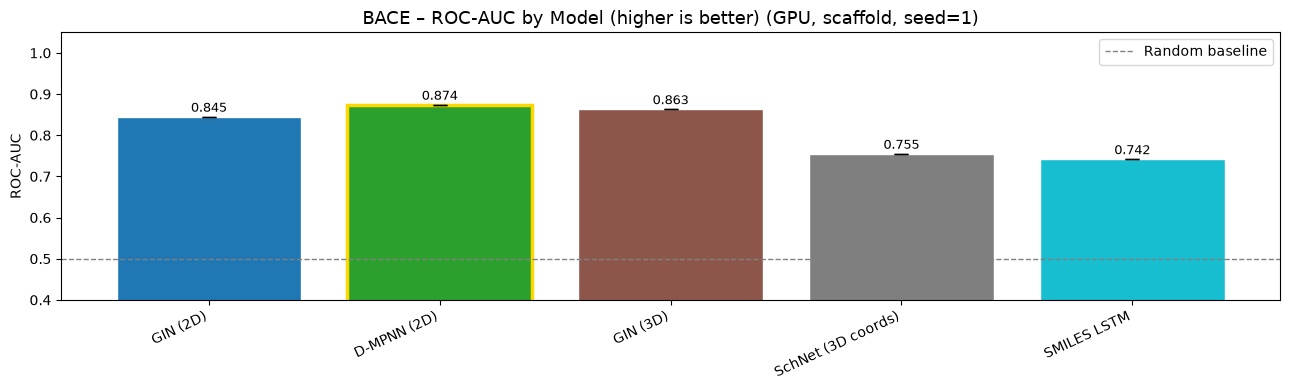

=== BACE Results (5/12 models) ===
                            ROC-AUC          PRC-AUC
Model                                               
GIN (2D)            0.8447 ± 0.0000  0.7484 ± 0.0000
D-MPNN (2D)         0.8739 ± 0.0000  0.7971 ± 0.0000
GIN (3D)            0.8631 ± 0.0000  0.8121 ± 0.0000
SchNet (3D coords)  0.7547 ± 0.0000  0.6819 ± 0.0000
SMILES LSTM         0.7418 ± 0.0000  0.6470 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/bace_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/bace_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/bace_partial.json


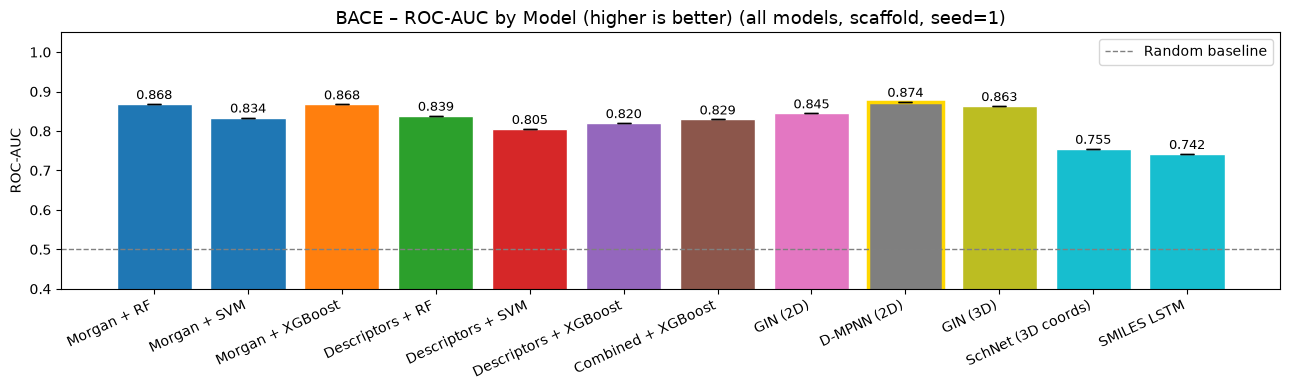

=== BACE Results (12/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.8682 ± 0.0000  0.7418 ± 0.0000
Morgan + SVM           0.8340 ± 0.0000  0.7237 ± 0.0000
Morgan + XGBoost       0.8675 ± 0.0000  0.7784 ± 0.0000
Descriptors + RF       0.8385 ± 0.0000  0.7000 ± 0.0000
Descriptors + SVM      0.8050 ± 0.0000  0.7122 ± 0.0000
Descriptors + XGBoost  0.8199 ± 0.0000  0.7019 ± 0.0000
Combined + XGBoost     0.8292 ± 0.0000  0.6875 ± 0.0000
GIN (2D)               0.8447 ± 0.0000  0.7484 ± 0.0000
D-MPNN (2D)            0.8739 ± 0.0000  0.7971 ± 0.0000
GIN (3D)               0.8631 ± 0.0000  0.8121 ± 0.0000
SchNet (3D coords)     0.7547 ± 0.0000  0.6819 ± 0.0000
SMILES LSTM            0.7418 ± 0.0000  0.6470 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/combined/bace_results.csv
Plot  

In [11]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"BACE – ROC-AUC by Model (higher is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"BACE – ROC-AUC by Model (higher is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
else:
    print("Run CPU notebook first for combined results.")
